# Tutorial 1: Atmospheric Observations and Simulations

Before diving into using ARTEMIS, lets look at how we can load our atmospheric concentration observations for a particular species and create corresponding forward simulations

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")
from mit_inversions.readers.observations import Observations
from mit_inversions.simulations import forward_simulation
from mit_inversions.readers.boundary_conditions import BoundaryConditions
from mit_inversions.plotting.plotting_observations import align_time_series, economist_timeseries_plot

Lets aim to make a plot of simulated and observed atmospheric concentrations of HFC-23 at Gosan, South Korea for the year 2023 in this notebook. The code presented can be easily adapted to include additional sites around the world. 

In [2]:
# Inputs
#   We can store our inputs in a dictionary for easy access and modification. This is especially useful if we want to run multiple simulations with different parameters.'
#  - species: The chemical species we want to analyze (e.g., "HFC-23").
# - sites: A list of observation sites to include in the analysis (e.g., ["GSN"]).
# - start_date: The start date for the time series data (e.g., "2023-01-01").
# - end_date: The end date for the time series data (e.g., "2024-01-01").
# - base_data_dir: The base directory where the AGAGE data is stored (e.g., "/net/fs01/data/AGAGE").
# - latest_release: A boolean indicating whether to use the latest release of the data (e.g., False).

data_dict = {
    "species": "HFC-23",
    "sites": ["GSN"],
    "start_date": "2023-01-01",
    "end_date": "2024-01-01",
    "base_data_dir": "/net/fs01/data/AGAGE",
    "latest_release": False,
}

In [3]:
# Initiate the Observations class with the specified parameters. This will load the relevant data for the specified species, sites, and date range.
setup_obs = Observations(species=data_dict["species"],
                         sites=data_dict["sites"],
                         start_date=data_dict["start_date"],
                         end_date=data_dict["end_date"],
                         base_data_path=data_dict["base_data_dir"],
                         latest_release=data_dict["latest_release"],
                         )

In [4]:
# Now we can retrieve the observations using the get_observations method. This will return a dictionary containing the time series data for each site.
obs_data = setup_obs.get_observations()

Loading observations ...


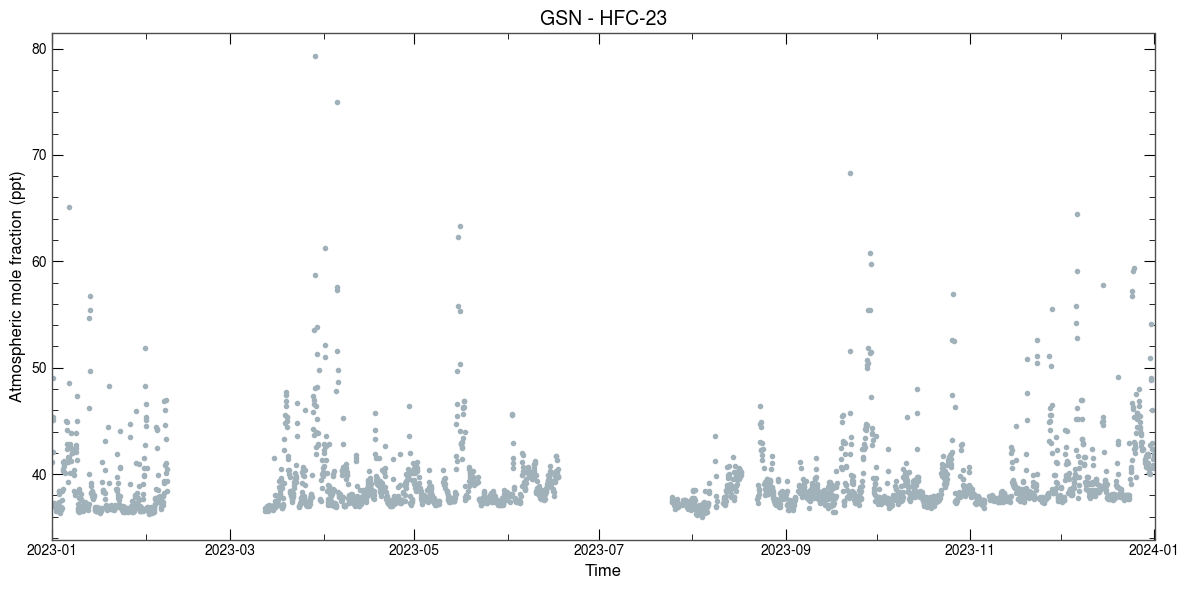

In [5]:
# And now if we want to plot those data ...
setup_obs.plot_timeseries(obs_data, unit="ppt")

Great! We can now see the plotted atmospheric observations of HFC-23 at Goson for the year 2023! Now lets see if we can make the simulated data that can be plotted alongside the observations.

First, we need to update some of the dictionary inputs!

In [ ]:
# We updated the inputs in the data_dict to include more parameters related to the footprints, such as LPDM model, meteorological model, and flux model. This allows us to have a more comprehensive set of inputs for our analysis and simulations.
data_dict_inputs = {
    "start_date": "2023-01-01",
    "end_date": "2024-01-01",
    "sites": ["GSN"],
    "species": "HFC-23",
    "base_data_dir": "/net/fs01/data/AGAGE/",


    "observations": {
        "latest_release": False,
        "average": None,
        },
    
    "footprints": {
        "site_inlets": None,
        "lpdm": "NAME",
        "met_model": "UMG",
        },

    "flux": {
        "mode": "customized",
        "path": "/net/fs01/data/AGAGE/flux_emissions/EDGARv8/HFC-23/EDGAR_2024_GHG_HFC-23_2023_TOTALS_flx.nc",
        "variable": "fluxes",
    }

}

We have added a dictionary with the variable args for fluxes. The key 'mode' is for when we want to use a specified flux grid (denoted by the path arg) with the data variable of the fluxes also given by 'variable'. We will explore the other option for this below!

In [7]:
# Create forward simulation - observation data object
model_obs_dict, flux_grid_prior = forward_simulation(data_dict_inputs)

Loading observations ...
Loading footprints data ...
Successfully loaded footprint data for GSN (202301) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202301.nc
Successfully loaded footprint data for GSN (202302) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202302.nc
Successfully loaded footprint data for GSN (202303) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202303.nc
Successfully loaded footprint data for GSN (202304) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202304.nc
Successfully loaded footprint data for GSN (202305) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202305.nc
Successfully loaded footprint data for GSN (202306) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202306.nc
Successfully loaded footprint data for GSN (202307) from /net/fs01/data/AGAGE/footprints/

/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Combining flux and footprint data ...


/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  flat_indexer = index.get_indexer(flat_labels, method=method, tolerance=tolerance)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  flat_indexer = index.get_indexer(flat_labels, method=method, tolerance=tolerance)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  flat_indexer = index.get_indexer(flat_labels, method=method, tolerance=tolerance)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H

The forward_simulation function only gets the added concentrations, to make a direct comparison with the atmospheric observations we need to calculate the baseline / background atmospheric mole fractions at the measurement site. These are calculated using the 12-box model outputs and can be called from the BoundaryConditions class

In [8]:
model_data_dict_bc = BoundaryConditions(species=data_dict_inputs["species"],
                                        fp_obj=model_obs_dict
                                        ).get_sensitivity_matrix()

Lets now make forward simulations using the other flux option 'auto_generation'

In [9]:
# We updated the inputs in the data_dict to include more parameters related to the footprints, such as LPDM model, meteorological model, and flux model. This allows us to have a more comprehensive set of inputs for our analysis and simulations.
data_dict_inputs = {
    "start_date": "2023-01-01",
    "end_date": "2024-01-01",
    "sites": ["GSN"],
    "species": "HFC-23",
    "base_data_dir": "/net/fs01/data/AGAGE/",


    "observations": {
        "latest_release": False,
        "average": None,
        },
    
    "footprints": {
        "site_inlets": None,
        "lpdm": "NAME",
        "met_model": "UMG",
        },

    "flux": {
        "mode": "auto_generation",
        "total_emissions_Gg": 45,
        "method": "population",
        "region": None,
    }

}

Notice that the arguments are very different when the 'auto_generation' option is used. A total emission for the region must be provided. This total emission for the region of interest will be spatially distributed according to one of the methods: "nightlights", "population", "uniform", "uniform_over_land". 

In the example above, we use the 'population' method to distribute the total emissions. 

In [10]:
model_obs_dict_2, flux_grid_prior_2 = forward_simulation(data_dict_inputs)

Loading observations ...
Loading footprints data ...
Successfully loaded footprint data for GSN (202301) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202301.nc
Successfully loaded footprint data for GSN (202302) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202302.nc
Successfully loaded footprint data for GSN (202303) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202303.nc
Successfully loaded footprint data for GSN (202304) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202304.nc
Successfully loaded footprint data for GSN (202305) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202305.nc
Successfully loaded footprint data for GSN (202306) from /net/fs01/data/AGAGE/footprints/name/gsn/GSN-10magl_NAME_UMG_EASTASIA_inert_202306.nc
Successfully loaded footprint data for GSN (202307) from /net/fs01/data/AGAGE/footprints/

/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  flat_indexer = index.get_indexer(flat_labels, method=method, tolerance=tolerance)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  flat_indexer = index.get_indexer(flat_labels, method=method, tolerance=tolerance)
/home/esaboya/miniconda3/envs/inversions_env_2/lib/python3.10/site-packages/xarray/core/indexes.py:630: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' ins

We can assign the data from these output dictionaries to some variables so it doesn't start getting too messy! We have to add the simulated background values to the added concentrations we simulated in the FootprintFlux class. 

In [11]:
x = model_obs_dict['GSN']['time'] 
y1 = model_obs_dict['GSN']['mf'] * 1e12
y2 = model_obs_dict['GSN']['mf_sim'].sum(dim="flux_sector") * 1e12 + model_data_dict_bc['GSN'].sum(dim="period_edge") * 1e12
y3 = model_obs_dict_2['GSN']['mf_sim'].sum(dim="flux_sector") * 1e12 + model_data_dict_bc['GSN'].sum(dim="period_edge") * 1e12

We're using a different timeseries plotting function as the Observations class inbuilt method wont' allow for multiple lines on the same graph. The economist_timeseries_plot function is useful for making clean plots for presentations or posters rather than 

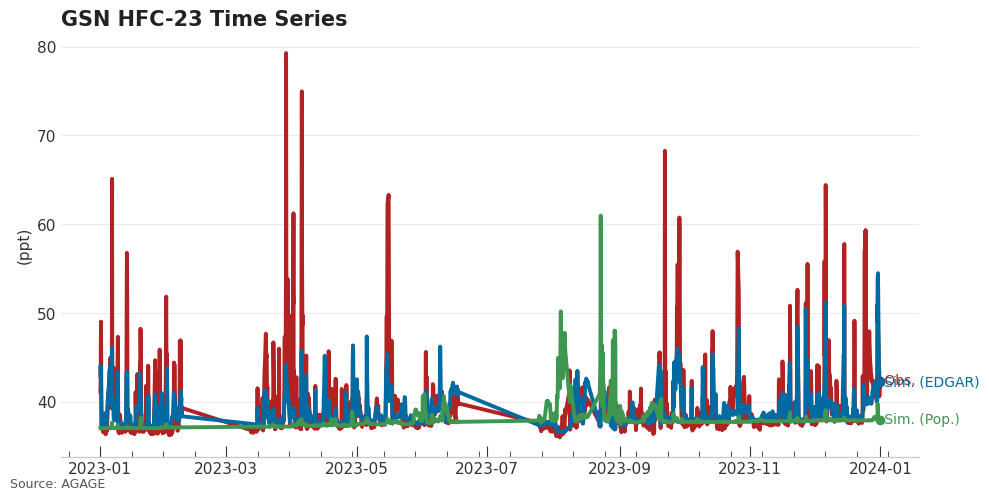

In [12]:
# Plot using the economist_timeseries_plot function, which is a custom plotting function designed to create time series plots in the style of The Economist magazine. 
# i.e. good for presentation plots! 

fig, ax = economist_timeseries_plot(x=model_obs_dict['GSN']['time'],
                          y1=y1,
                          y2=y2,
                          y3=y3,
                          labels=["Obs.", "Sim. (EDGAR)", "Sim. (Pop.)"],
                          title="GSN HFC-23 Time Series",
                          ylabel="(ppt)",
                          source="AGAGE",
)
plt.show()